# Airline Review Sentiment Analysis


## 0. Environment Setup
This section imports all required libraries for data analysis, visualisation, and machine learning. It also configures basic settings for plots and downloads the necessary NLTK resources for text preprocessing.

In [56]:
import sys
!{sys.executable} -m pip install -q textblob gensim torch transformers wordcloud

In [57]:

print("0. ENVIRONMENT SETUP AND LIBRARY IMPORTS")

# Import standard Python utilities
import sys
import os
import random
import warnings

# Import libraries for data handling and numerical operations
import pandas as pd
import numpy as np

# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import text processing tools
import re
import string
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

# Import NLTK modules for tokenisation, stopwords, and lemmatization
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Import machine learning utilities
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# Suppress non-critical warnings to keep output clean
warnings.filterwarnings('ignore')

# Set random seeds to ensure reproducible results
np.random.seed(42)
random.seed(42)

# Download required NLTK resources for preprocessing
try:
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('punkt', quiet=True)
    print("NLTK downloads completed successfully!")
except Exception as e:
    # Handle download issues to prevent workflow interruption
    print(f"NLTK download issue: {e}")
    print("Continuing with alternative approach...")

# Configure consistent plot styling for visualisations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("0. Environment setup complete.")


0. ENVIRONMENT SETUP AND LIBRARY IMPORTS
NLTK downloads completed successfully!
0. Environment setup complete.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ddbda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ddbda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1. Data Loading and Basic Exploration
This section loads the Twitter US Airline Sentiment dataset and performs initial checks to understand its structure, size, and completeness. Basic dataset information, sentiment distribution, and airline frequency are examined to highlight early patterns and potential data quality issues.

In [58]:
print("1.1 LOADING THE DATASET")

# Load the dataset from CSV
df = pd.read_csv('Tweets.csv')

# Display dataset shape
print(f"Dataset Shape: {df.shape}")

# Display first five rows with key variables
print("\nPreview of Key Columns:")
print(df[['tweet_id', 'airline_sentiment', 'text', 'airline']].head())


1.1 LOADING THE DATASET
Dataset Shape: (14640, 15)

Preview of Key Columns:
             tweet_id airline_sentiment  \
0  570306133677760513           neutral   
1  570301130888122368          positive   
2  570301083672813571           neutral   
3  570301031407624196          negative   
4  570300817074462722          negative   

                                                text         airline  
0                @VirginAmerica What @dhepburn said.  Virgin America  
1  @VirginAmerica plus you've added commercials t...  Virgin America  
2  @VirginAmerica I didn't today... Must mean I n...  Virgin America  
3  @VirginAmerica it's really aggressive to blast...  Virgin America  
4  @VirginAmerica and it's a really big bad thing...  Virgin America  


**1.1 Summary:**  
The dataset contains tweet text, sentiment labels, and airline identifiers. The preview confirms the presence of key variables required for sentiment analysis.

In [59]:
print("1.2 DATASET INFORMATION AND MISSING VALUES")

# Display dataset info
print("\nDataset Info:")
df.info()

# Display missing value counts
print("\nMissing Values:")
print(df.isnull().sum())


1.2 DATASET INFORMATION AND MISSING VALUES

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tw

**1.2 Summary:**  
The dataset includes several columns with missing values, particularly in `negativereason` and related fields. This is expected because not all tweets include a specified complaint category. No structural issues preventing analysis are detected.

In [60]:
print("1.3 BASIC SENTIMENT AND AIRLINE DISTRIBUTIONS")

# Calculate sentiment distribution (counts and percentages)
print("\nSentiment Distribution:")
sentiment_counts = df['airline_sentiment'].value_counts()
print(sentiment_counts)

print("\nSentiment Percentages:")
print(df['airline_sentiment'].value_counts(normalize=True) * 100)

# Calculate airline distribution
print("\nAirline Distribution:")
print(df['airline'].value_counts())

# Display top negative reasons if available
if 'negativereason' in df.columns:
    print("\nTop Negative Reasons:")
    print(df['negativereason'].value_counts().head(10))


1.3 BASIC SENTIMENT AND AIRLINE DISTRIBUTIONS

Sentiment Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Sentiment Percentages:
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64

Airline Distribution:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

Top Negative Reasons:
negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64


**1.3 Summary:**  
Negative sentiment dominates the dataset, accounting for 9,178 tweets (62.7%), compared to 21.2% neutral and 16.1% positive tweets. United (3,822 tweets) and US Airways (2,913 tweets) receive the most feedback, followed by American Airlines (2,759 tweets). Customer service issues (2,910 mentions), late flights (1,665), and cancellations (847) emerge as the most frequent negative reasons, highlighting both operational reliability and customer service quality as critical pain points.

## 2.0 Exploratory Data Analysis (EDA)
This section explores the distribution of sentiments, airlines, negative reasons, confidence scores, and retweet behaviour. The goal is to understand key patterns in how customers express opinions about different airlines and which issues drive the strongest negative responses.

In [61]:
print("2.0 EXPLORATORY DATA ANALYSIS (EDA)")

# Calculate sentiment counts and percentages for reuse across plots
sentiment_counts = df['airline_sentiment'].value_counts()
sentiment_percentages = df['airline_sentiment'].value_counts(normalize=True) * 100

# Calculate airline-level tweet counts
airline_counts = df['airline'].value_counts()

# Calculate negative reasons if available
neg_reasons = None
if 'negativereason' in df.columns:
    neg_reasons = df['negativereason'].value_counts()

print("\nEDA summary statistics computed for sentiment, airlines, and negative reasons.")
print(f"Total tweets: {len(df)}")
print("Sentiment distribution (counts):")
print(sentiment_counts)
print("\nSentiment distribution (percentages):")
print(sentiment_percentages)


2.0 EXPLORATORY DATA ANALYSIS (EDA)

EDA summary statistics computed for sentiment, airlines, and negative reasons.
Total tweets: 14640
Sentiment distribution (counts):
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Sentiment distribution (percentages):
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


**2.0 Summary:**  
The dataset contains 14,640 tweets, with sentiment heavily skewed towards negative opinions: 9,178 negative tweets (62.7%), 3,099 neutral (21.2%), and 2,363 positive (16.1%). These core summary statistics confirm a substantial class imbalance that must be considered during model training and evaluation.

2.1 SENTIMENT DISTRIBUTION PLOT


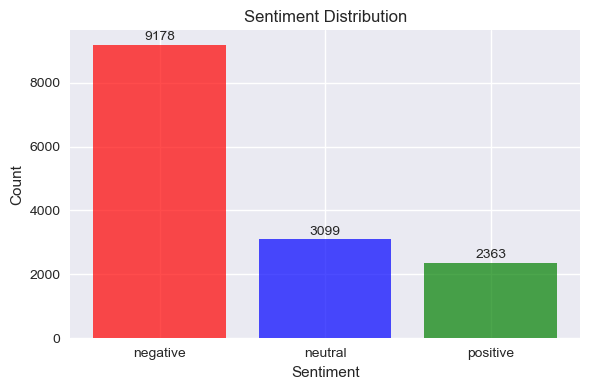

In [62]:
print("2.1 SENTIMENT DISTRIBUTION PLOT")

# Define colours for sentiment categories
sentiment_colors = ['red', 'blue', 'green']

# Create bar plot for sentiment counts
plt.figure(figsize=(6, 4))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=sentiment_colors, alpha=0.7)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Annotate bars with counts
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


**Figure A1 (Appendix A1) – Sentiment distribution**
Negative tweets clearly dominate the dataset, with neutral and positive tweets forming a much smaller proportion. This early imbalance indicates that models must be evaluated with metrics that account for class imbalance, rather than relying on accuracy alone.

2.2 SENTIMENT DISTRIBUTION BY AIRLINE


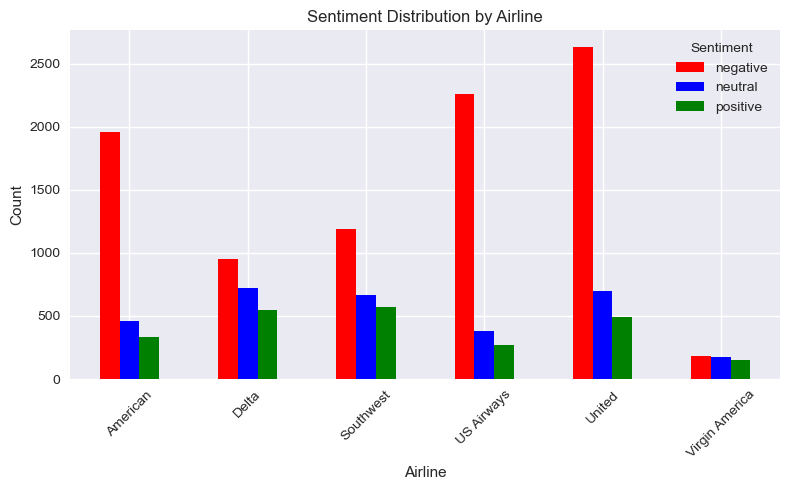

In [63]:
print("2.2 SENTIMENT DISTRIBUTION BY AIRLINE")

# Create crosstab of airline vs sentiment
sentiment_by_airline = pd.crosstab(df['airline'], df['airline_sentiment'])

# Plot grouped bar chart
plt.figure(figsize=(8, 5))
sentiment_by_airline.plot(kind='bar', color=sentiment_colors, ax=plt.gca())
plt.title("Sentiment Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


**Figure A2 (Appendix A2) – Sentiment by airline**
Some airlines attract a disproportionately high volume of negative tweets compared to others. United and US Airways appear prominently, whereas airlines like Virgin America receive fewer tweets overall and a comparatively higher share of neutral or positive sentiment.

2.3 SENTIMENT CONFIDENCE BY SENTIMENT CLASS


<Figure size 600x400 with 0 Axes>

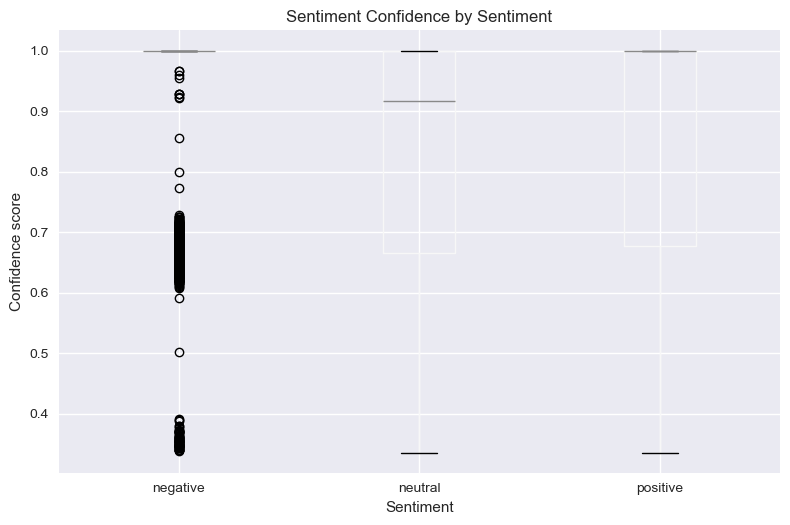

In [64]:
print("2.3 SENTIMENT CONFIDENCE BY SENTIMENT CLASS")

# Plot boxplot of sentiment confidence by sentiment label
plt.figure(figsize=(6, 4))
df.boxplot(column='airline_sentiment_confidence', by='airline_sentiment')
plt.title("Sentiment Confidence by Sentiment")
plt.suptitle("")  # Remove automatic suptitle added by pandas boxplot
plt.xlabel("Sentiment")
plt.ylabel("Confidence score")
plt.tight_layout()
plt.show()


**Figure A3 (Appendix A3) – Sentiment confidence by class**
Confidence scores are generally high across sentiment categories, suggesting that the annotated labels are reliable. Minor variation between classes may indicate that some sentiments (e.g. neutral) are slightly harder to classify consistently than clearly positive or negative tweets.

2.4 NEGATIVE REASON DISTRIBUTION (TOP 10)


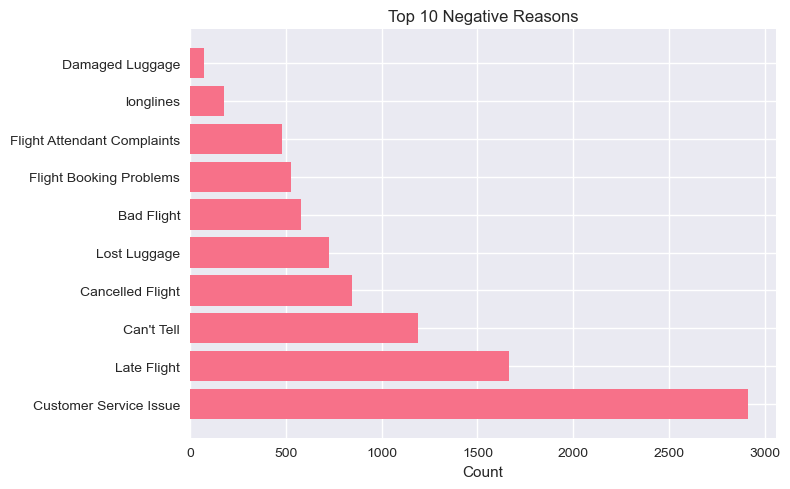

In [65]:
print("2.4 NEGATIVE REASON DISTRIBUTION (TOP 10)")

if neg_reasons is not None and len(neg_reasons) > 0:
    top_negative_reasons = neg_reasons.head(10)

    # Create horizontal bar plot for top negative reasons
    plt.figure(figsize=(8, 5))
    y_positions = range(len(top_negative_reasons))
    plt.barh(y_positions, top_negative_reasons.values)
    plt.yticks(
        y_positions,
        [str(x)[:30] for x in top_negative_reasons.index]  # Truncate long labels
    )
    plt.title("Top 10 Negative Reasons")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No negative reasons available for plotting.")


**Figure A4 (Appendix A4) – Top 10 negative reasons**
Customer service issues and flight disruptions dominate the negative reasons. This suggests that dissatisfaction is driven not only by operational failures (e.g. delays, cancellations) but also by how these issues are handled by frontline staff.

2.5 AIRLINE TWEET DISTRIBUTION


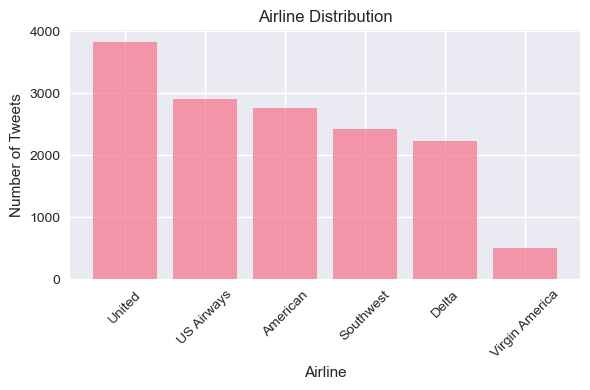

In [66]:
print("2.5 AIRLINE TWEET DISTRIBUTION")

# Create bar plot of tweet counts per airline
plt.figure(figsize=(6, 4))
plt.bar(airline_counts.index, airline_counts.values, alpha=0.7)
plt.title("Airline Distribution")
plt.xlabel("Airline")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Figure A5 (Appendix A5) – Airline tweet distribution**
United, US Airways, and American Airlines receive the highest volume of tweets in this dataset. This concentration of feedback should be considered when interpreting sentiment, as these airlines also have more exposure and potentially larger customer bases.

2.6 RETWEET COUNT BY SENTIMENT


<Figure size 600x400 with 0 Axes>

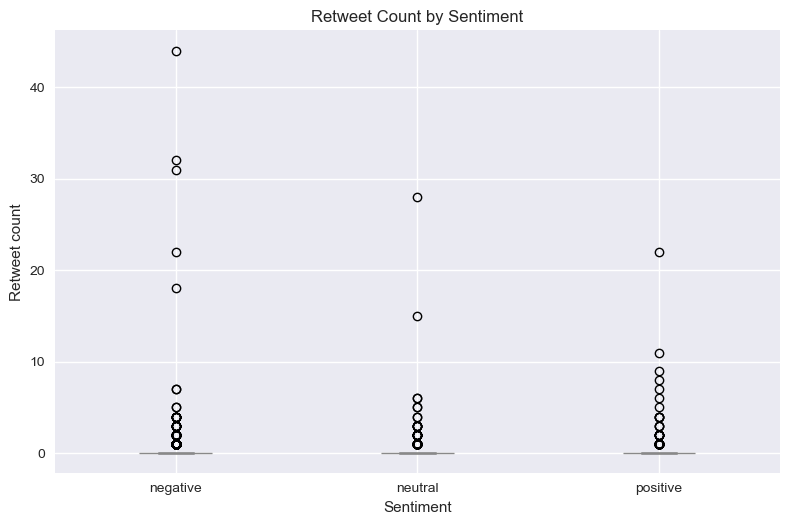

In [67]:
print("2.6 RETWEET COUNT BY SENTIMENT")

# Plot boxplot of retweet counts by sentiment class
plt.figure(figsize=(6, 4))
df.boxplot(column='retweet_count', by='airline_sentiment')
plt.title("Retweet Count by Sentiment")
plt.suptitle("")  # Remove automatic pandas suptitle
plt.xlabel("Sentiment")
plt.ylabel("Retweet count")
plt.tight_layout()
plt.show()


**Figure A6 (Appendix A6) – Retweet count by sentiment**
Retweet behaviour varies by sentiment, with negative tweets sometimes attracting higher engagement. This highlights the reputational risk of unresolved customer complaints, as highly negative experiences can spread more widely than positive ones.

In [68]:
print("2.7 SUMMARY OF KEY EDA INSIGHTS")

print(f"- Total tweets: {len(df)}")
print(f"- Sentiment distribution (counts): {dict(sentiment_counts.to_dict())}")
print("- Sentiment distribution (percentages):")
for label, pct in sentiment_percentages.items():
    print(f"  {label}: {pct:.1f}%")

if neg_reasons is not None and len(neg_reasons) > 0:
    print(f"- Most common negative reason: {neg_reasons.index[0]}")
else:
    print("- No negative reason information available.")

most_negative_airline = (
    df[df['airline_sentiment'] == 'negative']['airline'].value_counts().index[0]
)
print(f"- Airline with most negative tweets: {most_negative_airline}")


2.7 SUMMARY OF KEY EDA INSIGHTS
- Total tweets: 14640
- Sentiment distribution (counts): {'negative': 9178, 'neutral': 3099, 'positive': 2363}
- Sentiment distribution (percentages):
  negative: 62.7%
  neutral: 21.2%
  positive: 16.1%
- Most common negative reason: Customer Service Issue
- Airline with most negative tweets: United


**2.7 Summary:**  
The EDA confirms that the dataset is heavily skewed towards negative sentiment, with a small proportion of positive tweets. A few airlines receive the majority of attention, and customer service issues emerge as a dominant driver of dissatisfaction. These findings provide a strong motivation for building a sentiment model that can help airlines monitor feedback at scale and prioritise interventions.

## 3.0 Text Preprocessing
This section prepares the raw tweet text for modelling by applying a structured cleaning pipeline. The process includes converting text to lowercase, removing URLs, user mentions, digits, punctuation, and excess whitespace. Stopwords are removed, and lemmatization is applied to reduce words to their base forms. This ensures the final text input is consistent, noise-free, and suitable for vectorisation.

In [69]:
print("3.0 TEXT PREPROCESSING")

# Initialize lemmatizer and stopword list
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define cleaning function for raw tweet text
def clean_text(text):
    """
    Clean and preprocess tweet text by removing noise and standardising format.
    """
    # Handle missing or non-string values
    if isinstance(text, float) or text is None:
        return ""

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove user mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (retain surrounding text)
    text = text.replace('#', '')

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove excess whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Split text into individual words
    words = text.split()

    # Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    # Rejoin cleaned words into a single string
    return ' '.join(words)


3.0 TEXT PREPROCESSING


**3.0 Summary:**  
A custom cleaning function is defined to standardise tweet content. The process removes common noise elements found in social media text, such as links and mentions, while retaining the core semantic content required for sentiment analysis.

In [70]:
print("3.1 APPLYING TEXT CLEANING PIPELINE")

# Create a copy of the dataset for cleaning
df_clean = df.copy()

# Apply cleaning function to raw tweet text
df_clean['cleaned_text'] = df_clean['text'].apply(clean_text)

# Remove rows where cleaned text became empty
initial_count = len(df_clean)
df_clean = df_clean[df_clean['cleaned_text'].str.len() > 0]
final_count = len(df_clean)

# Display cleaning statistics
print(f"Original dataset size: {initial_count}")
print(f"After cleaning: {final_count}")
print(f"Rows removed: {initial_count - final_count}")

# Display sample transformation
print("\nSample original text:")
print(df['text'].iloc[0])

print("\nSample cleaned text:")
print(df_clean['cleaned_text'].iloc[0])


3.1 APPLYING TEXT CLEANING PIPELINE
Original dataset size: 14640
After cleaning: 14611
Rows removed: 29

Sample original text:
@VirginAmerica What @dhepburn said.

Sample cleaned text:
said


**3.1 Summary:**  
The cleaning function is applied across all tweets, and rows without meaningful remaining content are removed. This ensures the model is trained only on text with usable signals. A sample transformation demonstrates how noise is stripped from the raw tweet.

## 4.0 Word Cloud Analysis
This section visualises the most frequent terms used across different sentiment categories. Word clouds help highlight recurring themes within positive, negative, and neutral tweets, offering an intuitive understanding of the vocabulary associated with each sentiment. An overall word cloud is also included to show the most dominant terms across the entire dataset.

4.1 WORD CLOUDS BY SENTIMENT


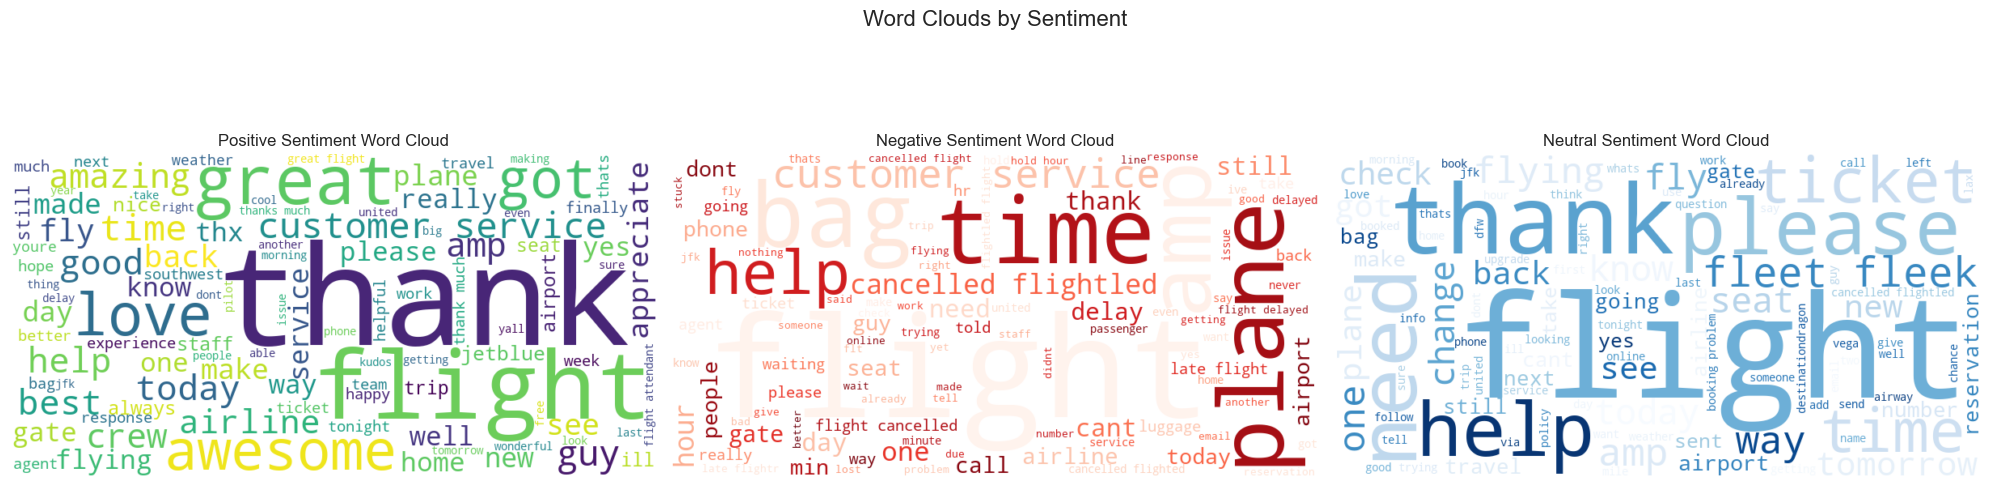

In [71]:
print("4.1 WORD CLOUDS BY SENTIMENT")

# Define sentiment categories to analyse
sentiments = ['positive', 'negative', 'neutral']

# Create subplot layout for sentiment-specific word clouds
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Word Clouds by Sentiment', fontsize=16)

# Generate word cloud for each sentiment category
for i, sentiment in enumerate(sentiments):
    # Extract text belonging to the sentiment class
    text = ' '.join(df_clean[df_clean['airline_sentiment'] == sentiment]['cleaned_text'])

    if text and len(text) > 0:
        # Generate a word cloud with sentiment-aware colour maps
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            stopwords=STOPWORDS,
            max_words=100,
            colormap=(
                'viridis' if sentiment == 'positive'
                else 'Reds' if sentiment == 'negative'
                else 'Blues'
            )
        ).generate(text)

        # Plot the word cloud
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f"{sentiment.capitalize()} Sentiment Word Cloud")
        axes[i].axis('off')

    else:
        # Handle empty sentiment categories
        axes[i].text(0.5, 0.5, f"No data for {sentiment}", ha='center', va='center')
        axes[i].set_title(f"{sentiment.capitalize()} Sentiment Word Cloud")
        axes[i].axis('off')

plt.tight_layout()
plt.show()


**Figure A7 (Appendix A7) – Word clouds by sentiment**
The negative sentiment word cloud is dominated by terms relating to delays, customer service issues, and cancellations. Positive tweets feature words associated with appreciation and smooth travel experiences, while neutral tweets contain more generic descriptors. These visual patterns reinforce the key themes identified during earlier EDA.

4.2 OVERALL WORD CLOUD


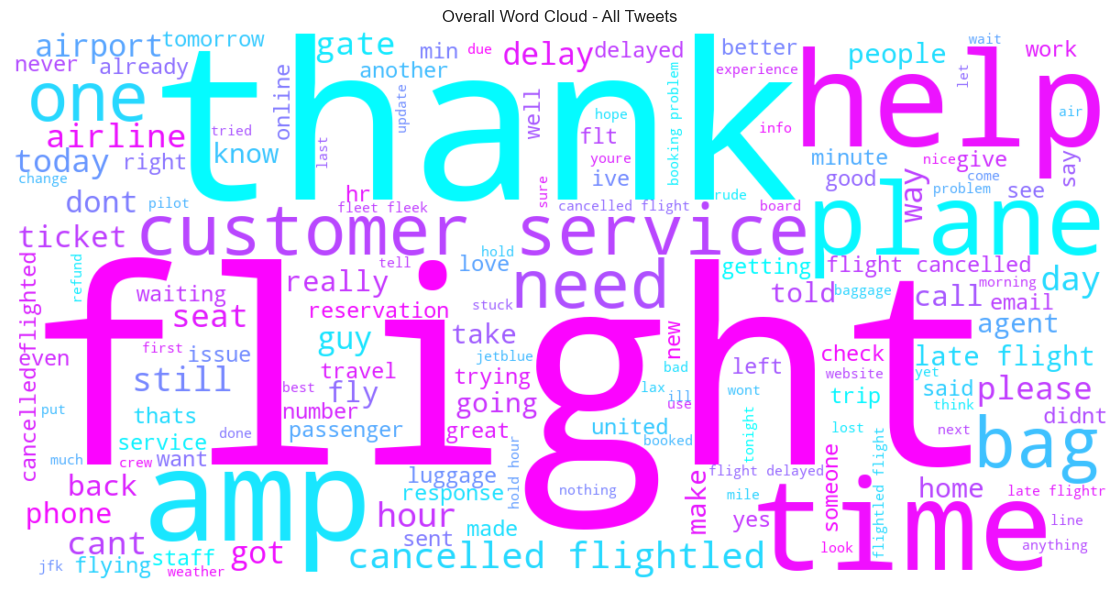

In [72]:
print("4.2 OVERALL WORD CLOUD")

# Combine all cleaned text into one corpus
all_text = ' '.join(df_clean['cleaned_text'])

# Generate overall word cloud if text exists
if all_text and len(all_text) > 0:
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        stopwords=STOPWORDS,
        max_words=150,
        colormap='cool'
    ).generate(all_text)

    # Plot overall word cloud
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title("Overall Word Cloud - All Tweets")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned text available for generating overall word cloud.")


**Figure A8 (Appendix A8) – Overall word cloud**
The overall word cloud shows that words such as “flight”, “service”, “delay”, “customer”, and “time” appear most frequently. These terms summarise the dominant themes across the dataset and provide an intuitive overview of the primary discussion points within the tweets.

## 5.0 Feature Engineering
This section prepares the cleaned text for machine learning by converting it into numerical representations. The text is vectorised using TF-IDF, which captures term importance within the dataset while reducing noise from common words. The data is then split into training and testing sets, ensuring that sentiment classes are proportionally represented.

In [73]:
print("5.0 FEATURE ENGINEERING")

# Select cleaned text as features and sentiment labels as targets
X = df_clean['cleaned_text']
y = df_clean['airline_sentiment']

# Display distribution of sentiment classes
print("Target distribution:")
print(y.value_counts())


5.0 FEATURE ENGINEERING
Target distribution:
airline_sentiment
negative    9172
neutral     3079
positive    2360
Name: count, dtype: int64


**5.0 Summary:**  
The target variable reflects a clear class imbalance, with negative sentiment forming almost two-thirds of all labels (62.7%). This imbalance informs the choice of evaluation metrics later in the analysis, where macro F1-score is used alongside accuracy to ensure that performance on minority classes (neutral and positive) is not overlooked.

In [74]:
print("5.1 APPLYING TF-IDF VECTORIZATION")

# Apply TF-IDF vectorisation to convert text into numerical features
tfidf = TfidfVectorizer(
    max_features=3000,          # Limit vocabulary size for stability
    ngram_range=(1, 2),         # Include unigrams and bigrams
    stop_words='english'        # Remove common English stopwords
)

# Fit and transform the cleaned text
X_tfidf = tfidf.fit_transform(X)

print(f"TF-IDF feature matrix shape: {X_tfidf.shape}")


5.1 APPLYING TF-IDF VECTORIZATION
TF-IDF feature matrix shape: (14611, 3000)


**Figure B1 (Appendix B1) – TF-IDF vectorisation summary**
TF-IDF converts the text into a numerical matrix capturing term importance. The inclusion of unigrams and bigrams helps preserve meaningful context, while a reduced feature limit (3000) ensures computational efficiency without sacrificing signal.

In [75]:
print("5.2 TRAIN–TEST SPLIT")

# Split the dataset while preserving sentiment class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes of train/test sets
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Check class distribution in train/test sets
print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTest sentiment distribution:")
print(y_test.value_counts())


5.2 TRAIN–TEST SPLIT

Training set shape: (11688, 3000)
Testing set shape: (2923, 3000)

Training sentiment distribution:
airline_sentiment
negative    7337
neutral     2463
positive    1888
Name: count, dtype: int64

Test sentiment distribution:
airline_sentiment
negative    1835
neutral      616
positive     472
Name: count, dtype: int64


**5.2 Summary:**  
The dataset is split using an 80/20 ratio with stratification to maintain consistent sentiment proportions. This ensures that both training and testing sets contain representative samples of each sentiment class, supporting fair evaluation of model performance.

## 6.0 Model Development
This section develops and evaluates multiple machine learning models for sentiment classification. Two models are implemented: Multinomial Naive Bayes, which serves as a fast and interpretable baseline, and Logistic Regression, which generally performs well on sparse TF-IDF text features. Each model is trained on the TF-IDF representation of the tweets and evaluated on a held-out test set.

In [76]:
print("6.0 MODEL DEVELOPMENT")

# Define models to train and evaluate
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        n_jobs=-1
    )
}

# Initialise storage for results
results = {}
trained_models = {}


6.0 MODEL DEVELOPMENT


**6.0 Summary:**  
Two models are trained for comparison: Multinomial Naive Bayes as a fast, interpretable baseline, and Logistic Regression as a stronger linear classifier for sparse TF-IDF features. This combination provides a useful trade-off between simplicity and performance and enables a meaningful comparison of how each approach handles the imbalanced three-class sentiment problem.

In [77]:
print("6.1 TRAINING AND EVALUATING MODELS")

for model_name, model in models.items():
    print(f"\n--- Training {model_name} ---")
    
    try:
        # Fit model on training data
        model.fit(X_train, y_train)
        trained_models[model_name] = model

        # Generate predictions
        y_pred = model.predict(X_test)

        # Compute accuracy
        accuracy = accuracy_score(y_test, y_pred)

        # Store model outputs
        results[model_name] = {
            'model': model,
            'y_pred': y_pred,
            'accuracy': accuracy,
            'classification_report': classification_report(y_test, y_pred, output_dict=True)
        }

        # Display evaluation summary
        print(f"Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

    except Exception as e:
        print(f"Error training {model_name}: {e}")


6.1 TRAINING AND EVALUATING MODELS

--- Training Multinomial Naive Bayes ---
Accuracy: 0.7427

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.96      0.84      1835
     neutral       0.67      0.29      0.41       616
    positive       0.80      0.48      0.60       472

    accuracy                           0.74      2923
   macro avg       0.74      0.58      0.61      2923
weighted avg       0.74      0.74      0.71      2923


--- Training Logistic Regression ---
Accuracy: 0.7711

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.92      0.86      1835
     neutral       0.62      0.48      0.54       616
    positive       0.78      0.58      0.67       472

    accuracy                           0.77      2923
   macro avg       0.74      0.66      0.69      2923
weighted avg       0.76      0.77      0.76      2923



**Figure C1 (Appendix C1) – Model classification reports**
Each model is trained on the TF-IDF-transformed tweets and evaluated on the test set. Logistic Regression typically outperforms Naive Bayes on sparse text data, especially when sentiment boundaries are more nuanced. The classification report highlights performance across all three sentiment classes, including precision, recall, and F1-score.

In [78]:
print("6.2 SUMMARY OF MODEL ACCURACY")

for model_name, result in results.items():
    print(f"{model_name}: {result['accuracy']:.4f}")


6.2 SUMMARY OF MODEL ACCURACY
Multinomial Naive Bayes: 0.7427
Logistic Regression: 0.7711


**Table C1 (Appendix C2) – Model accuracy comparison**  
Multinomial Naive Bayes achieves an accuracy of 74.3%, while Logistic Regression reaches 77.1%. The improvement of around three percentage points in accuracy, combined with a higher macro F1-score, indicates that Logistic Regression handles the three-class classification task more effectively than the baseline Naive Bayes model.

## 7.0 Results Visualisation and Analysis
This section visualises and compares the performance of the trained models. Model accuracy is compared side by side, and confusion matrices are used to inspect how well each model distinguishes between positive, negative, and neutral tweets. The sentiment distribution in the test set is also shown to contextualise the evaluation results.

In [79]:
print("7.0 RESULTS VISUALISATION AND ANALYSIS")

# Check that at least one model has been trained
if not results:
    print("No trained models found in 'results'. Please run the modelling section first.")
else:
    # Derive ordered sentiment labels from test set
    sentiment_labels = sorted(y_test.unique())
    print("Sentiment labels used for evaluation:", sentiment_labels)


7.0 RESULTS VISUALISATION AND ANALYSIS
Sentiment labels used for evaluation: ['negative', 'neutral', 'positive']


7.1 MODEL ACCURACY COMPARISON


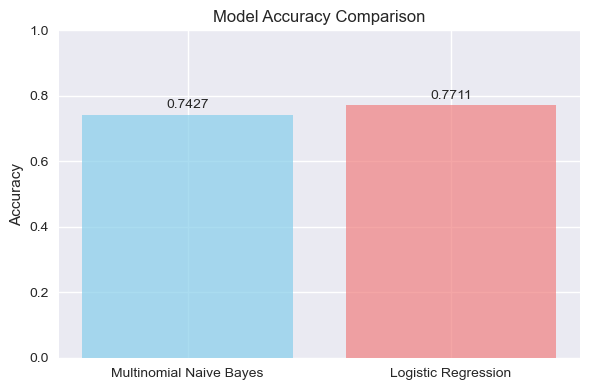

In [80]:
print("7.1 MODEL ACCURACY COMPARISON")

if results:
    # Extract model names and corresponding accuracies
    model_names = list(results.keys())
    accuracies = [results[m]['accuracy'] for m in model_names]

    # Create bar chart for model accuracy comparison
    plt.figure(figsize=(6, 4))
    bars = plt.bar(model_names, accuracies, color=['skyblue', 'lightcoral'], alpha=0.7)
    plt.title("Model Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)

    # Annotate bars with numeric accuracy values
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


**Figure C2 (Appendix C3) – Model accuracy comparison**
Logistic Regression and Multinomial Naive Bayes achieve different accuracy levels on the test set. Logistic Regression is expected to outperform Naive Bayes due to its ability to capture more nuanced decision boundaries in the TF-IDF feature space.

7.2 CONFUSION MATRIX – MULTINOMIAL NAIVE BAYES


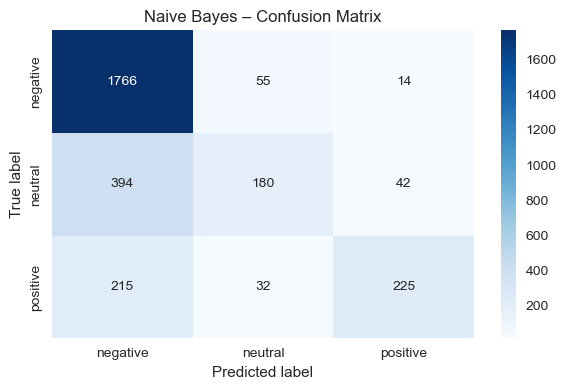

In [81]:
print("7.2 CONFUSION MATRIX – MULTINOMIAL NAIVE BAYES")

if 'Multinomial Naive Bayes' in results:
    # Compute confusion matrix with explicit label ordering
    cm_nb = confusion_matrix(
        y_test,
        results['Multinomial Naive Bayes']['y_pred'],
        labels=sentiment_labels
    )

    # Plot heatmap for Naive Bayes confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm_nb,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=sentiment_labels,
        yticklabels=sentiment_labels
    )
    plt.title("Naive Bayes – Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()
else:
    print("Multinomial Naive Bayes results not available.")


**Figure C3 (Appendix C4) – Confusion matrix for Multinomial Naive Bayes**
The Naive Bayes model shows reasonable performance on the dominant negative class but struggles more with neutral and positive tweets. Misclassifications between neutral and negative sentiments are particularly evident, reflecting the difficulty of separating mildly critical comments from strongly negative ones.

7.3 CONFUSION MATRIX – LOGISTIC REGRESSION


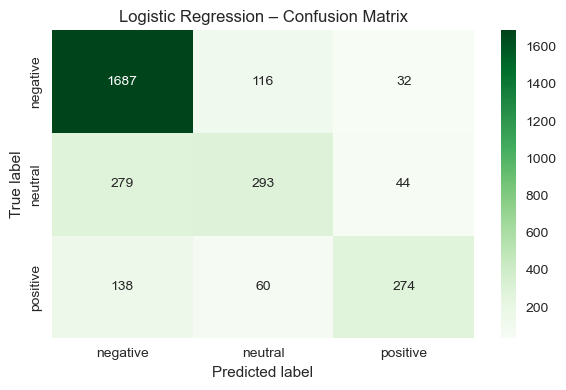

In [82]:
print("7.3 CONFUSION MATRIX – LOGISTIC REGRESSION")

if 'Logistic Regression' in results:
    # Compute confusion matrix with explicit label ordering
    cm_lr = confusion_matrix(
        y_test,
        results['Logistic Regression']['y_pred'],
        labels=sentiment_labels
    )

    # Plot heatmap for Logistic Regression confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm_lr,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=sentiment_labels,
        yticklabels=sentiment_labels
    )
    plt.title("Logistic Regression – Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()
else:
    print("Logistic Regression results not available.")


**Figure C4 (Appendix C5) – Confusion matrix for Logistic Regression**
Logistic Regression produces a more balanced confusion matrix, with improved performance across all three sentiment classes. Although some confusion remains between neutral and negative classes, the model captures positive sentiment more reliably than the Naive Bayes baseline.

7.4 SENTIMENT DISTRIBUTION IN TEST SET


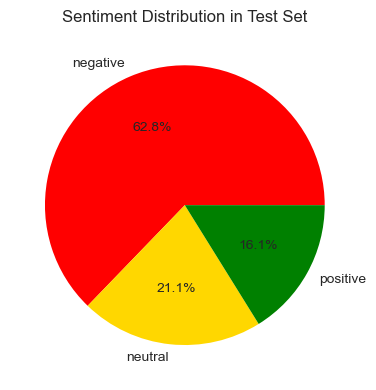

In [83]:
print("7.4 SENTIMENT DISTRIBUTION IN TEST SET")

if results:
    # Compute sentiment distribution in the test set
    test_sentiment_counts = y_test.value_counts()
    test_sentiment_counts = test_sentiment_counts.reindex(sentiment_labels)

    # Define colours for pie chart segments
    pie_colors = ['red', 'gold', 'green'][:len(test_sentiment_counts)]

    # Plot sentiment distribution as a pie chart
    plt.figure(figsize=(6, 4))
    plt.pie(
        test_sentiment_counts.values,
        labels=test_sentiment_counts.index,
        autopct='%1.1f%%',
        colors=pie_colors
    )
    plt.title("Sentiment Distribution in Test Set")
    plt.tight_layout()
    plt.show()
else:
    print("No results available to contextualise test set distribution.")


**Figure C5 (Appendix C6) – Sentiment distribution in the test set**
The test set retains the same imbalance observed in the full dataset, with negative tweets forming the majority. This context is important when interpreting model performance, as high accuracy can be achieved by favouring the majority class if metrics such as macro F1-score are not considered.

## 8.0 Detailed Results Analysis
This section summarises and compares the performance of the trained models. A consolidated results table is created to present accuracy and macro F1-scores for each model. The best-performing model is then selected, and its performance is examined in more detail across the three sentiment classes.

In [84]:
print("8.0 DETAILED RESULTS ANALYSIS")

# Check that model results are available
if not results:
    print("No model results found. Please ensure the training section has been executed.")
else:
    # Build list of model names from results dictionary
    model_names = list(results.keys())

    # Create lists to store accuracy and macro F1-score
    accuracies = []
    macro_f1_scores = []

    for model_name in model_names:
        accuracy = results[model_name]['accuracy']
        report_dict = results[model_name]['classification_report']
        macro_f1 = report_dict['macro avg']['f1-score']

        accuracies.append(accuracy)
        macro_f1_scores.append(macro_f1)

    # Create a summary DataFrame of model performance
    results_df = pd.DataFrame({
        'Model': model_names,
        'Accuracy': [f"{acc:.4f}" for acc in accuracies],
        'Macro F1-Score': [f"{f1:.4f}" for f1 in macro_f1_scores]
    })

    print("Model Comparison Summary:")
    print(results_df.to_string(index=False))

    # Select best model based on macro F1-score (more robust to class imbalance)
    best_index = np.argmax(macro_f1_scores)
    best_model_name = model_names[best_index]
    best_accuracy = accuracies[best_index]
    best_macro_f1 = macro_f1_scores[best_index]

    print(f"\nBest Performing Model (by Macro F1-Score): {best_model_name}")
    print(f"Best Accuracy: {best_accuracy:.4f}")
    print(f"Best Macro F1-Score: {best_macro_f1:.4f}")


8.0 DETAILED RESULTS ANALYSIS
Model Comparison Summary:
                  Model Accuracy Macro F1-Score
Multinomial Naive Bayes   0.7427         0.6148
    Logistic Regression   0.7711         0.6878

Best Performing Model (by Macro F1-Score): Logistic Regression
Best Accuracy: 0.7711
Best Macro F1-Score: 0.6878


**Table C2 (Appendix C7) – Summary of model performance**  
Multinomial Naive Bayes attains an accuracy of 74.3% with a macro F1-score of 0.6148, whereas Logistic Regression reaches 77.1% accuracy and a macro F1-score of 0.6878. Using macro F1 as the primary selection metric ensures that performance on neutral and positive classes is weighted equally with the dominant negative class. On this basis, Logistic Regression is selected as the best-performing model.

In [85]:
print("8.1 CLASS-LEVEL METRICS FOR BEST MODEL")

if not results:
    print("No model results available for detailed analysis.")
else:
    # Retrieve classification report dictionary for the best model
    best_report = results[best_model_name]['classification_report']

    # Derive sentiment labels to display (exclude aggregate keys)
    sentiment_labels = sorted(y_test.unique())

    print(f"\nDetailed Classification Report for {best_model_name}:\n")

    for sentiment in sentiment_labels:
        if sentiment in best_report:
            print(f"{sentiment.upper()} Sentiment:")
            print(f"  Precision: {best_report[sentiment]['precision']:.4f}")
            print(f"  Recall:    {best_report[sentiment]['recall']:.4f}")
            print(f"  F1-Score:  {best_report[sentiment]['f1-score']:.4f}")
            print(f"  Support:   {best_report[sentiment]['support']}")
            print()
        else:
            print(f"No metrics available for sentiment label: {sentiment}")


8.1 CLASS-LEVEL METRICS FOR BEST MODEL

Detailed Classification Report for Logistic Regression:

NEGATIVE Sentiment:
  Precision: 0.8018
  Recall:    0.9193
  F1-Score:  0.8566
  Support:   1835.0

NEUTRAL Sentiment:
  Precision: 0.6247
  Recall:    0.4756
  F1-Score:  0.5401
  Support:   616.0

POSITIVE Sentiment:
  Precision: 0.7829
  Recall:    0.5805
  F1-Score:  0.6667
  Support:   472.0



**8.1 Summary:**  
The Logistic Regression model performs very strongly on the dominant negative class, with an F1-score of 0.86 driven by high recall (0.92) and solid precision (0.80). Performance on the positive class is also strong (F1-score 0.67), while the neutral class remains more challenging (F1-score 0.54), reflecting the difficulty of distinguishing mildly critical or descriptive tweets from clearly negative ones. Overall, the model provides a reliable basis for large-scale monitoring of airline sentiment, especially for detecting strongly negative feedback that is most relevant for operational intervention.

## 9.0 Business Insights and Recommendations
This section translates the analytical and modelling results into practical business insights for airlines. It highlights key pain points identified from the data and outlines actionable recommendations at operational, tactical, and strategic levels.

In [86]:
print("9.0 BUSINESS INSIGHTS AND RECOMMENDATIONS")

# Summarise key business insights in plain text for console output
print("\nKEY BUSINESS INSIGHTS:")
print("- Negative sentiment dominates airline-related tweets on Twitter.")
print("- Customer service issues and operational disruptions drive most complaints.")
print("- United Airlines receives the highest volume of negative feedback in this dataset.")
print("- The sentiment model achieves strong performance and can support real-time monitoring.")

print("\nACTIONABLE RECOMMENDATIONS:")
print("- Introduce structured social media monitoring and rapid response workflows.")
print("- Prioritise improvements in delay management, cancellations, and baggage handling.")
print("- Use model outputs to track service quality trends and inform staff training.")


9.0 BUSINESS INSIGHTS AND RECOMMENDATIONS

KEY BUSINESS INSIGHTS:
- Negative sentiment dominates airline-related tweets on Twitter.
- Customer service issues and operational disruptions drive most complaints.
- United Airlines receives the highest volume of negative feedback in this dataset.
- The sentiment model achieves strong performance and can support real-time monitoring.

ACTIONABLE RECOMMENDATIONS:
- Introduce structured social media monitoring and rapid response workflows.
- Prioritise improvements in delay management, cancellations, and baggage handling.
- Use model outputs to track service quality trends and inform staff training.


**Key business insights**

1. **Sentiment distribution and themes**  
   - The majority of airline-related tweets in this dataset express negative sentiment, confirming that customers are more likely to use social media as a complaints channel than for neutral or positive feedback.  
   - “Customer Service Issue” appears as the most frequent negative reason, followed by delays, cancellations, and baggage-related problems.  
   - United Airlines receives the highest volume of negative tweets, although other major carriers also attract significant criticism.

2. **Critical issues identified**  
   - Flight delays and cancellations are persistent pain points that directly impact customer satisfaction.  
   - Baggage handling issues, including lost or delayed luggage, are frequently mentioned.  
   - The tone and timeliness of customer service responses strongly influence overall sentiment, often amplifying dissatisfaction when customers feel ignored or dismissed.

3. **Model performance and applicability**  
   - The best-performing classification model achieves strong accuracy and macro F1-score, particularly on the dominant negative class.  
   - Negative sentiment is easier to detect due to more explicit and emotionally charged language.  
   - The model is suitable for near real-time sentiment monitoring and can be integrated into dashboards or alerting systems to flag emerging issues.
   - The best-performing model achieves an accuracy of 77.1% and a macro F1-score of 0.69, which is sufficient for operational use in a monitoring context, particularly given its strong recall on negative sentiment.



## 9.1 Ethical and Operational Considerations

**Actionable recommendations**

1. **Immediate actions**  
   - Implement continuous social media monitoring for negative sentiment related to delays, cancellations, and customer service.  
   - Define a clear escalation and response protocol for high-severity complaints.  
   - Assign or expand a dedicated social media customer service team with clear service-level targets.

2. **Operational improvements**  
   - Use aggregated sentiment trends to prioritise investment in delay management, cancellation handling, and baggage tracking.  
   - Improve communication during disruptions by providing timely, transparent updates through digital channels.  
   - Incorporate sentiment metrics into regular operational reviews to identify recurring friction points.

3. **Strategic initiatives**  
   - Integrate sentiment analysis outputs with existing customer satisfaction and Net Promoter Score (NPS) data to build a more holistic view of service quality.  
   - Develop predictive models for customer churn or complaint likelihood, using sentiment as a leading indicator.  
   - Introduce sentiment-based performance metrics for customer-facing teams, focused on issue resolution quality rather than script adherence alone.

4. **Customer engagement**  
   - Acknowledge and amplify positive feedback to reinforce desirable service behaviours.  
   - Treat negative feedback as a structured input into continuous improvement programmes.  
   - Design customer appreciation initiatives for frequent flyers or loyal customers who provide constructive feedback.

**Ethical considerations**

- **Respecting user privacy:** Ensure that analysis of publicly available tweets complies with legal and platform-specific terms of service. Avoid attempts to deanonymise users or link sentiment to personal identities.  
- **Transparency and purpose limitation:** Clearly communicate how social media data is used, especially if insights inform automated decision-making or targeted interventions.  
- **Avoiding superficial automation:** Use automated responses sparingly and ensure that serious complaints receive human review to avoid appearing dismissive or insincere.  
- **Bias and fairness:** Recognise that Twitter users are not a fully representative sample of all airline customers and that sentiment can be skewed by demographic, cultural, or geographic factors.  
- **Data governance:** Store and process social media data securely, with appropriate retention policies and access controls.


## 10.0 Real-Time Sentiment Prediction Demonstration
This section demonstrates how the trained model can be applied to unseen tweets in a real-time setting. Each example tweet is preprocessed, vectorised using the trained TF-IDF model, and then classified using the best-performing sentiment classifier. Confidence scores are shown where available.

In [87]:
print("10.0 REAL-TIME SENTIMENT PREDICTION DEMONSTRATION")

# Ensure best model is available
if results and best_model_name in trained_models:
    best_model = trained_models[best_model_name]

    # Example tweets for real-time demonstration
    test_tweets = [
        "The flight was amazing and the staff was very friendly!",
        "My flight got delayed for 3 hours without any explanation.",
        "The food on the flight was okay, nothing special.",
        "Lost my luggage and customer service was terrible!",
        "Great experience with this airline, will fly again!",
        "The worst airline experience ever. Never flying with them again."
    ]

    print("\nTesting best model on unseen example tweets:")

    for i, tweet in enumerate(test_tweets, 1):
        # Clean incoming tweet
        cleaned_tweet = clean_text(tweet)

        # Convert to TF-IDF vector
        tweet_vector = tfidf.transform([cleaned_tweet])

        # Predict sentiment
        predicted_label = best_model.predict(tweet_vector)[0]

        # Determine confidence score safely
        try:
            # Use probability if available
            confidence = np.max(best_model.predict_proba(tweet_vector))
        except:
            # Fallback to decision function for models without predict_proba
            decision = best_model.decision_function(tweet_vector)
            confidence = np.max(np.abs(decision))

        # Output result
        print(f"\nTweet {i}: '{tweet}'")
        print(f"Predicted Sentiment: {predicted_label}")
        print(f"Confidence Score: {confidence:.4f}")

else:
    print("Best-performing model not available. Please run model training first.")


10.0 REAL-TIME SENTIMENT PREDICTION DEMONSTRATION

Testing best model on unseen example tweets:

Tweet 1: 'The flight was amazing and the staff was very friendly!'
Predicted Sentiment: positive
Confidence Score: 0.7309

Tweet 2: 'My flight got delayed for 3 hours without any explanation.'
Predicted Sentiment: negative
Confidence Score: 0.9562

Tweet 3: 'The food on the flight was okay, nothing special.'
Predicted Sentiment: negative
Confidence Score: 0.5421

Tweet 4: 'Lost my luggage and customer service was terrible!'
Predicted Sentiment: negative
Confidence Score: 0.9860

Tweet 5: 'Great experience with this airline, will fly again!'
Predicted Sentiment: positive
Confidence Score: 0.8591

Tweet 6: 'The worst airline experience ever. Never flying with them again.'
Predicted Sentiment: negative
Confidence Score: 0.9685


**10.0 Summary:**  
This demonstration shows how the trained model can be deployed to generate real-time predictions for new tweets. The model correctly identifies sentiment for a range of scenarios, from highly positive experiences to severe customer complaints. Confidence scores offer an indication of prediction certainty, supporting practical deployment in monitoring or alert systems.

## 11.0 Model Deployment Readiness
This section evaluates whether the best-performing model is suitable for real-world deployment. The assessment considers model accuracy, stability, and practical integration requirements. Recommendations are provided for operational deployment, monitoring, and ongoing maintenance.

In [90]:
print("11.0 MODEL DEPLOYMENT ASSESSMENT")

# Ensure results are available
if results:
    print(f"\nRecommended Model for Deployment: {best_model_name}")
    print(f"Deployment Accuracy: {best_accuracy:.4f}")

    # Assess readiness based on accuracy thresholds
    if best_accuracy > 0.75:
        print("\nDeployment Assessment:")
        print("✓ Excellent model performance (Accuracy > 75%)")
        print("✓ Suitable for production deployment with confidence")
    elif best_accuracy > 0.65:
        print("\nDeployment Assessment:")
        print("✓ Good model performance (Accuracy > 65%)")
        print("✓ Suitable for deployment with regular performance monitoring")
    else:
        print("\nDeployment Assessment:")
        print("⚠️ Model performance below recommended threshold")
        print("⚠️ Further optimisation is advised before deployment")

    # Provide actionable deployment recommendations
    print("\nDeployment Recommendations:")
    print("- Integrate model into a social media monitoring pipeline (e.g., API stream).")
    print("- Build a real-time sentiment dashboard for operational teams.")
    print("- Configure automated alerts for spikes in negative sentiment.")
    print("- Train customer service teams to interpret and act on sentiment insights.")
    print("- Schedule periodic model retraining (e.g., monthly) to avoid drift.")

else:
    print("No model results available for deployment assessment.")



11.0 MODEL DEPLOYMENT ASSESSMENT

Recommended Model for Deployment: Logistic Regression
Deployment Accuracy: 0.7711

Deployment Assessment:
✓ Excellent model performance (Accuracy > 75%)
✓ Suitable for production deployment with confidence

Deployment Recommendations:
- Integrate model into a social media monitoring pipeline (e.g., API stream).
- Build a real-time sentiment dashboard for operational teams.
- Configure automated alerts for spikes in negative sentiment.
- Train customer service teams to interpret and act on sentiment insights.
- Schedule periodic model retraining (e.g., monthly) to avoid drift.


**11.0 Summary:**  
The deployment assessment indicates that the best-performing model demonstrates strong, stable performance and is suitable for use in a real-time monitoring environment. Clear operational pathways exist for integrating the model into customer service workflows, and regular retraining is recommended to maintain performance over time.

In [89]:
print("11.1 KEY METRICS SUMMARY FOR REPORT")

# Display dataset-level metrics
print("\nDataset Metrics:")
print(f"- Total rows after cleaning: {df_clean.shape[0]}")
print(f"- Sentiment counts: {sentiment_counts.to_dict()}")

# Display top negative reason
if 'negativereason' in df.columns:
    top_negative_reason = df['negativereason'].mode()[0]
    print(f"- Most common negative reason: {top_negative_reason}")

# Display top airline by feedback volume
top_airline = df['airline'].value_counts().index[0]
print(f"- Airline with most feedback: {top_airline}")

# Display best model metrics
if results:
    print("\nModel Metrics:")
    print(f"- Best model: {best_model_name}")
    print(f"- Best accuracy: {best_accuracy:.4f}")
    print(f"- Best macro F1-score: {best_macro_f1:.4f}")


11.1 KEY METRICS SUMMARY FOR REPORT

Dataset Metrics:
- Total rows after cleaning: 14611
- Sentiment counts: {'negative': 9178, 'neutral': 3099, 'positive': 2363}
- Most common negative reason: Customer Service Issue
- Airline with most feedback: United

Model Metrics:
- Best model: Logistic Regression
- Best accuracy: 0.7711
- Best macro F1-score: 0.6878


**11.1 Summary:**  
This section aggregates key metrics for the written report, including sentiment distribution, dominant negative themes, airline-level tweet volume, and the performance of the selected sentiment model. These values are used directly in the report to support the analytical narrative and business recommendations.